## 1. 먼저 해찬님과 같이 더블체크한 그래프 (일반 8개 그래프) 

1. 총 발송 수

2. 총 열람 수

3. 총 완료 수

4. 전체 완료율 (%)

5. 총 오퍼 연계 매출 (다중 오퍼 = 멀티 있는 것으로 추가 수정)

6. 발송 1건당 평균 매출

7. 오퍼 1건당 평균 매출

8. 오퍼별 ARPU (다중 오퍼 = 멀티 있는 것으로 추가 수정)

## 2. 이전에 했던 오퍼별 채널별 성과 요약 & 시각화

### 대시보드 1 : 전체 (핵심지표 소개)

##### 1-1. 총 오퍼 퍼널 분석 (총 발송 수, 총 열람 수, 총 완료 수)

##### 1-2. 총 오퍼 퍼널 분석 (오퍼 단계별 전환율)

##### 2. 총 매출

##### 3. 총 거래 건수

##### 4. 거래 건당 객단가

##### 5. 전체 고객 수

##### 6. 채널별 고객 수

##### 7. completed 된 거래 중 viewed 단계 여부

##### 8. 오퍼 종류 별 고객이 completed까지 걸리는 time 평균

### 대시보드 2 : 오퍼/체널별 성과 요약

##### 1-1. 총 발송 수

##### 1-2. 총 열람 수

##### 1-3. 총 완료 수

##### 1-4. 전체 완료율

##### 2. 오퍼 효율 분석 (산점도)

-----

# 일반 8개 그래프 그리기

In [3]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


### 스타벅스 공식 컬러 팔레트 정의

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

SB_DEEP_GREEN = '#1E3932'
SB_GREEN      = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD       = '#CBA258'
SB_GREY       = '#A2AAAD'
SB_BLACK      = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic',
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})


sns.set_palette([SB_GREEN, SB_GOLD, SB_DEEP_GREEN, SB_LIGHT_GREEN, SB_GREY])

In [5]:
merge_df = pd.read_csv("../../Data/merged_df_260325.csv")
trans = pd.read_csv("../../Data/transactions_260325.csv")

In [6]:
trans.head()

,tx_key,person,customer_id,time,amount,tx_occurrence,time_days,gender,age,became_member_on,income,income_missing,age_missing,linked_reward_offer_cnt,reward_offer_family_list,reward_offer_label_list,reward_offer_id_list,bonus_reward_sum,tx_offer_type
0,0009655768c64bdeb2e877511632db8f|228|22.16|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,228,22.16,1,10,M,33.0,2017-04-21,72000.0,0,0,0,[],[],[],0,normal
1,0009655768c64bdeb2e877511632db8f|414|8.57|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,414,8.57,1,18,M,33.0,2017-04-21,72000.0,0,0,1,['bogo'],['bogo_4'],['f19421c1d4aa40978ebb69ca19b0e20d'],5,bogo
2,0009655768c64bdeb2e877511632db8f|528|14.11|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,528,14.11,1,23,M,33.0,2017-04-21,72000.0,0,0,1,['discount'],['discount_3'],['fafdcd668e3743c1bb461111dcafc2a4'],2,discount
3,0009655768c64bdeb2e877511632db8f|552|13.56|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,552,13.56,1,24,M,33.0,2017-04-21,72000.0,0,0,0,[],[],[],0,normal
4,0009655768c64bdeb2e877511632db8f|576|10.27|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,576,10.27,1,25,M,33.0,2017-04-21,72000.0,0,0,1,['discount'],['discount_4'],['2906b810c7d4411798c6938adc9daaa5'],2,discount


In [7]:
print(merge_df.info())

display(merge_df.head(5))

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306137 non-null  str    
 1   event             306137 non-null  str    
 2   time              306137 non-null  int64  
 3   offer_id          167184 non-null  str    
 4   amount            138953 non-null  float64
 5   bonus_reward      33182 non-null   float64
 6   time_days         306137 non-null  int64  
 7   gender            306137 non-null  str    
 8   age               272388 non-null  float64
 9   customer_id       306137 non-null  str    
 10  became_member_on  306137 non-null  str    
 11  income            272388 non-null  float64
 12  income_missing    306137 non-null  int64  
 13  age_missing       306137 non-null  int64  
 14  reward            167184 non-null  float64
 15  difficulty        167184 non-null  float64
 16  duration          167184 non-nu

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label
0,0009655768c64bdeb2e877511632db8f,completed,576,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,25,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,2,0,0.0,NaN
1,0009655768c64bdeb2e877511632db8f,received,576,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,25,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,0,1,1.0,NaN
2,0009655768c64bdeb2e877511632db8f,received,336,3f207df678b143eea3cee63160fa8bed,NaN,NaN,15,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,4.0,1.0,1.0,1.0,0.0,informational_1,0,1,1.0,NaN
3,0009655768c64bdeb2e877511632db8f,viewed,372,3f207df678b143eea3cee63160fa8bed,NaN,NaN,16,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,4.0,1.0,1.0,1.0,0.0,informational_1,1,0,1.0,NaN
4,0009655768c64bdeb2e877511632db8f,received,168,5a8bc65990b245e5a138643cd4eb9837,NaN,NaN,8,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,informational_2,0,1,1.0,NaN


## Viewed 기록 중복 확인 코드

In [8]:
viewed_df = merge_df[merge_df['event'] == 'viewed']
viewed_df.head(2)

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label
3,0009655768c64bdeb2e877511632db8f,viewed,372,3f207df678b143eea3cee63160fa8bed,NaN,NaN,16,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,4.0,1.0,1.0,1.0,0.0,informational_1,1,0,1.0,NaN
5,0009655768c64bdeb2e877511632db8f,viewed,192,5a8bc65990b245e5a138643cd4eb9837,NaN,NaN,9,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,0.0,0.0,3.0,0.0,1.0,1.0,1.0,informational_2,1,0,1.0,NaN


사람, 오퍼 아이디, 시간 모두 보기

In [9]:
view_counts = viewed_df.groupby(['person', 'offer_label','time']).size().reset_index(name='count')
view_counts

,person,offer_label,time,count
0,0009655768c64bdeb2e877511632db8f,bogo_4,456,1
1,0009655768c64bdeb2e877511632db8f,discount_3,540,1
2,0009655768c64bdeb2e877511632db8f,informational_1,372,1
3,0009655768c64bdeb2e877511632db8f,informational_2,192,1
4,00116118485d4dfda04fdbaba9a87b5c,bogo_4,216,1
...,...,...,...,...
57720,ffff82501cea40309d5fdd7edcca4a07,discount_1,174,1
57721,ffff82501cea40309d5fdd7edcca4a07,discount_3,6,1
57722,ffff82501cea40309d5fdd7edcca4a07,discount_4,354,1
57723,ffff82501cea40309d5fdd7edcca4a07,discount_4,414,1


중복 나오지 않음

In [10]:
multiple_views = view_counts[view_counts['count'] > 1]

if len(multiple_views) > 0:
    print(f"중복 {len(multiple_views)}건")
    display(multiple_views.sort_values(by='count', ascending=False).head(10))
else:
    print("오퍼를 딱 한 번씩만 열람")

오퍼를 딱 한 번씩만 열람


In [11]:
duplicated_views = viewed_df[viewed_df.duplicated(subset=['person', 'offer_label'], keep=False)]

duplicated_views_sorted = duplicated_views.sort_values(by=['person', 'offer_label', 'time'])
display(duplicated_views_sorted[['person', 'offer_label', 'time', 'event']].head(10))

,person,offer_label,time,event
21,00116118485d4dfda04fdbaba9a87b5c,bogo_4,216,viewed
23,00116118485d4dfda04fdbaba9a87b5c,bogo_4,630,viewed
94,003d66b6608740288d6cc97a6903f4f0,discount_3,300,viewed
97,003d66b6608740288d6cc97a6903f4f0,discount_3,420,viewed
158,004c5799adbf42868b9cff0396190900,bogo_4,408,viewed
161,004c5799adbf42868b9cff0396190900,bogo_4,516,viewed
164,004c5799adbf42868b9cff0396190900,discount_3,174,viewed
168,004c5799adbf42868b9cff0396190900,discount_3,648,viewed
185,005500a7188546ff8a767329a2f7c76a,bogo_1,60,viewed
187,005500a7188546ff8a767329a2f7c76a,bogo_1,186,viewed


사람 & offer label로만 봤을 때 중복되는 데이터 보기 -> time은 다른 것을 볼 수 있음

**시간이 다르기 때문에 중복이 아니라고 판단**

## 1. 총 발송 수 

오퍼 수신 이벤트만 골라서

총 몇 건의 오퍼가 뿌려졌는지 계산

오퍼를 받은 사람 수도 세보자

In [12]:
# 오퍼 수신 이벤트 (informational 제외)
received_df = merge_df[merge_df['event']=='received']

target_info = ['informational_1', 'informational_2']
received_df = received_df[~received_df['offer_label'].isin(target_info)]

# 총 몇 건의 오퍼
total_received_count = len(received_df)

# 오퍼를 받은 총 고객 수
unique_receivers = received_df['person'].nunique()

print(f"스타벅스가 뿌린 총 오퍼 건수: {total_received_count:,} 건")
print(f"오퍼를 받은 총 고객 수: {unique_receivers:,} 명")

스타벅스가 뿌린 총 오퍼 건수: 61,042 건
오퍼를 받은 총 고객 수: 16,928 명


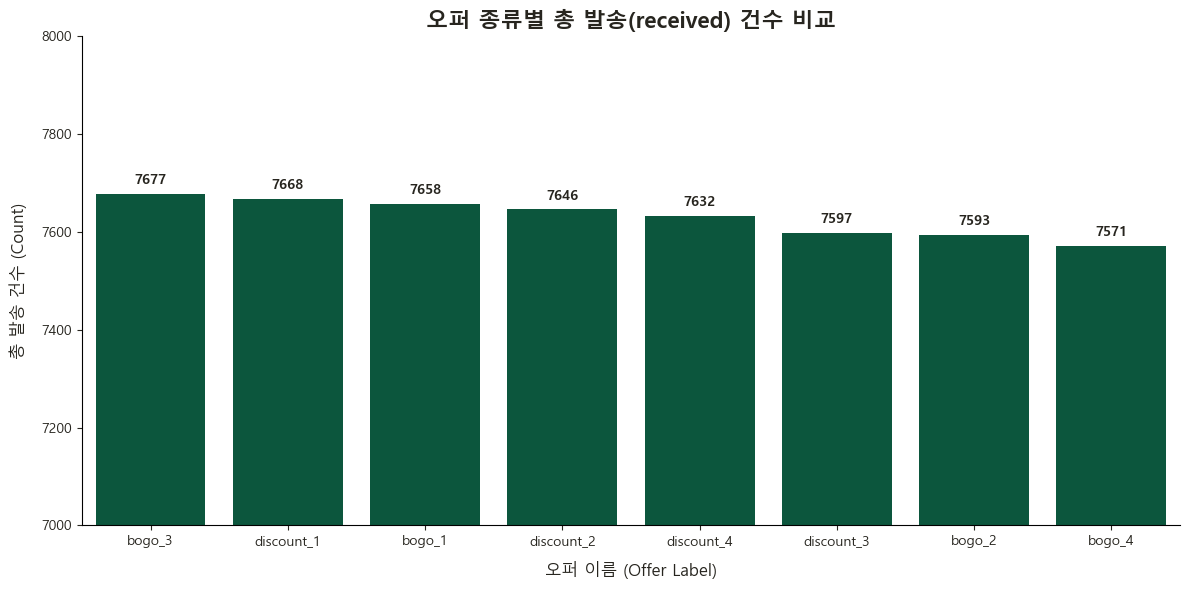

In [13]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=received_df, 
    x='offer_label', 
    order=received_df['offer_label'].value_counts().index
)
# y축 조절
plt.ylim(7000, 8000)

plt.title('오퍼 종류별 총 발송(received) 건수 비교', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('총 발송 건수 (Count)', fontsize=12, labelpad=10)

ax.bar_label(ax.containers[0], fmt='%d', padding=5, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. 총 열람 수 

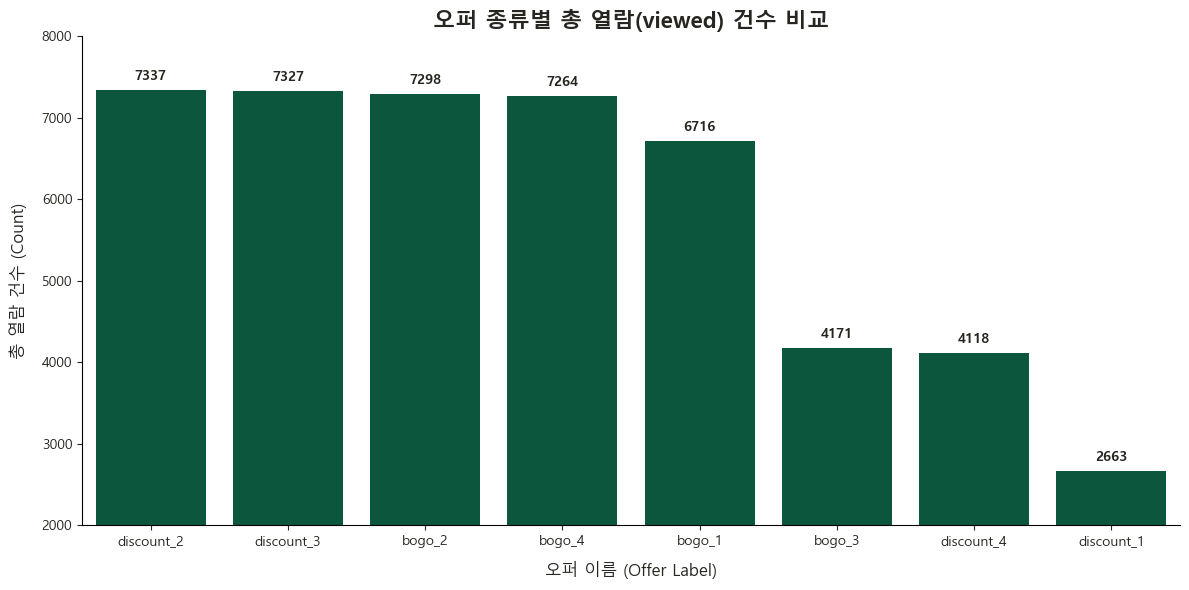

In [14]:
viewed_df = merge_df[merge_df['event'] == 'viewed']

target_info = ['informational_1', 'informational_2']
viewed_df = viewed_df[~viewed_df['offer_label'].isin(target_info)]

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=viewed_df, 
    x='offer_label', 
    order=viewed_df['offer_label'].value_counts().index
)

ax.bar_label(ax.containers[0], fmt='%d', padding=5, fontweight='bold', color=SB_BLACK)

plt.ylim(2000, 8000)

plt.title('오퍼 종류별 총 열람(viewed) 건수 비교', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('총 열람 건수 (Count)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

## 3. 총 완료 수

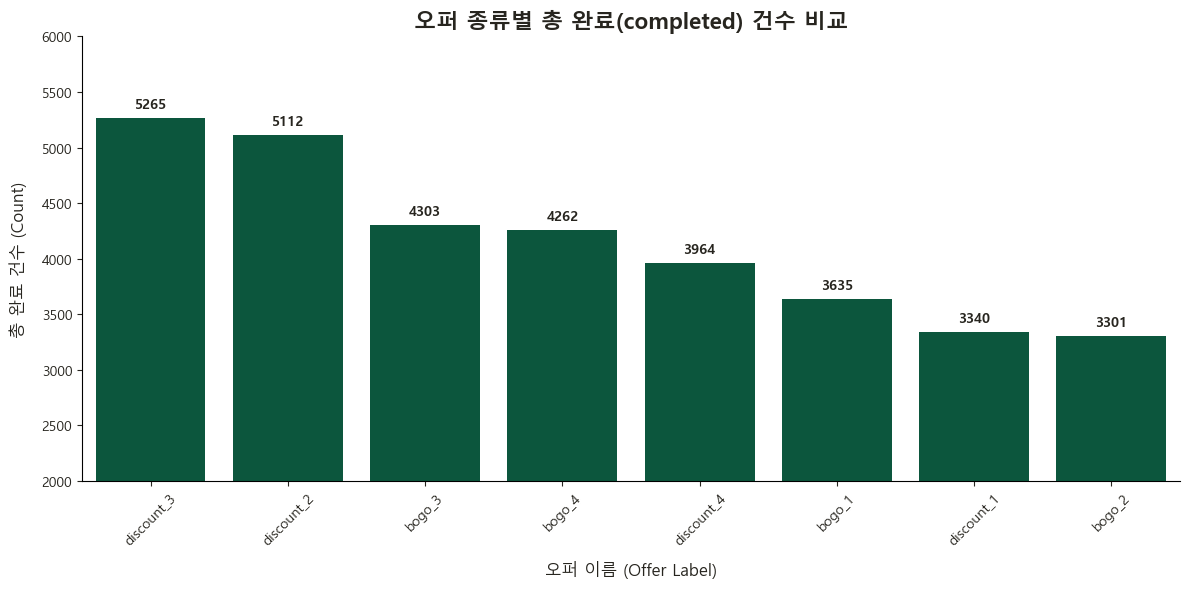

In [15]:
completed_df = merge_df[merge_df['event'] == 'completed']

target_info = ['informational_1', 'informational_2']
completed_df = completed_df[~completed_df['offer_label'].isin(target_info)]

plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=completed_df, 
    x='offer_label', 
    order=completed_df['offer_label'].value_counts().index
)

ax.bar_label(ax.containers[0], fmt='%d', padding=5, fontweight='bold', color=SB_BLACK)

plt.ylim(2000, 6000)

plt.title('오퍼 종류별 총 완료(completed) 건수 비교', fontsize=16, fontweight='bold')
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('총 완료 건수 (Count)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 4. 전체 완료율(%)



발송과 완료의 비율 비교

완료율(%) = (완료 수 / 발송 수) * 100

In [16]:
import pandas as pd

# 1. 오퍼별로 발송(received) 건수
received_counts = received_df.groupby('offer_label').size().reset_index(name='received_count')

# 2. 오퍼별로 완료(completed) 건수
completed_counts = completed_df.groupby('offer_label').size().reset_index(name='completed_count')

# 3. 두 데이터를 'offer_label'을 기준으로 하나로 합침
funnel_df = pd.merge(received_counts, completed_counts, on='offer_label', how='left')

# 4. 완료율(%) = (완료 수 / 발송 수) * 100
funnel_df['completion_rate(%)'] = (funnel_df['completed_count'] / funnel_df['received_count']) * 100

funnel_df = funnel_df.sort_values(by='completion_rate(%)', ascending=False).reset_index(drop=True)


display(funnel_df.style.format({
    'received_count': '{:,} 건', 
    'completed_count': '{:,} 건',
    'completion_rate(%)': '{:.2f} %'
}))

,offer_label,received_count,completed_count,completion_rate(%)
0,discount_3,"7,597 건","5,265 건",69.30 %
1,discount_2,"7,646 건","5,112 건",66.86 %
2,bogo_4,"7,571 건","4,262 건",56.29 %
3,bogo_3,"7,677 건","4,303 건",56.05 %
4,discount_4,"7,632 건","3,964 건",51.94 %
5,bogo_1,"7,658 건","3,635 건",47.47 %
6,discount_1,"7,668 건","3,340 건",43.56 %
7,bogo_2,"7,593 건","3,301 건",43.47 %


In [17]:
print(received_counts.head(2))
print(completed_counts.head(2))

  offer_label  received_count
0      bogo_1            7658
1      bogo_2            7593
  offer_label  completed_count
0      bogo_1             3635
1      bogo_2             3301


#### 전체 완료율 그래프

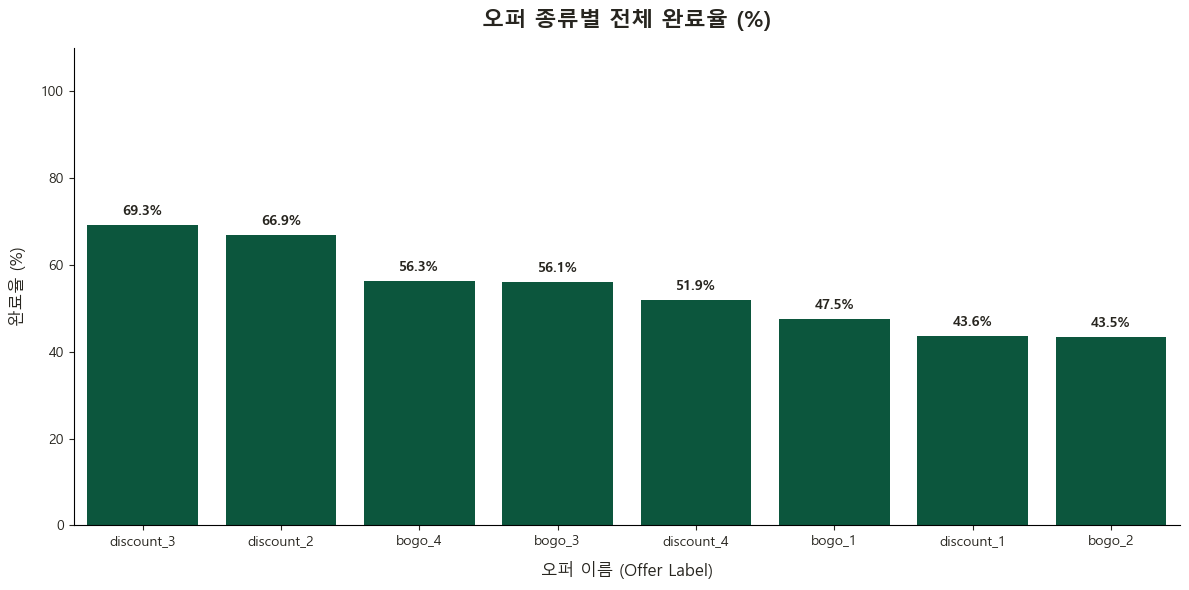

In [18]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=funnel_df, 
    x='offer_label', 
    y='completion_rate(%)'
)

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5, fontweight='bold', color=SB_BLACK)

plt.ylim(0, 110)

plt.title('오퍼 종류별 전체 완료율 (%)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('완료율 (%)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

## 5. 총 오퍼 연계 매출 ($)

left join이후 쿠폰을 쓰고 결제한 경우에는 offer_label이 붙는다.

일반 결제는 offer_label이 nan

In [19]:
print(completed_df.head())

                              person      event  time  \
0   0009655768c64bdeb2e877511632db8f  completed   576   
7   0009655768c64bdeb2e877511632db8f  completed   414   
10  0009655768c64bdeb2e877511632db8f  completed   528   
29  0011e0d4e6b944f998e987f904e8c1e5  completed   576   
32  0011e0d4e6b944f998e987f904e8c1e5  completed   252   

                            offer_id  amount  bonus_reward  time_days gender  \
0   2906b810c7d4411798c6938adc9daaa5     NaN           2.0         25      M   
7   f19421c1d4aa40978ebb69ca19b0e20d     NaN           5.0         18      M   
10  fafdcd668e3743c1bb461111dcafc2a4     NaN           2.0         23      M   
29  0b1e1539f2cc45b7b9fa7c272da2e1d7     NaN           5.0         25      O   
32  2298d6c36e964ae4a3e7e9706d1fb8c2     NaN           3.0         11      O   

     age                       customer_id became_member_on   income  \
0   33.0  0009655768c64bdeb2e877511632db8f       2017-04-21  72000.0   
7   33.0  0009655768c64bdeb2e877

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 결제 데이터 준비
transactions_df = merge_df[merge_df['event'] == 'transaction'][['person', 'time', 'amount']]
completed_df = merge_df[merge_df['event']=='completed'][['person','time','offer_label']]
# 2. left join
sales_df = pd.merge(transactions_df, completed_df[['person', 'time', 'offer_label']], on=['person', 'time'], how='left')
# 3. 카테고리 분류기 (일반 결제 / discount / bogo)
def get_payment_category(label):
    if pd.isna(label): 
        return '일반 결제'
    elif 'discount' in str(label).lower(): 
        return 'discount'
    elif 'bogo' in str(label).lower(): 
        return 'bogo'
    else:
        return '기타'

# category 컬럼
sales_df['category'] = sales_df['offer_label'].apply(get_payment_category)

# 4. 카테고리별로 매출액(amount) 총합
revenue_summary = sales_df.groupby('category')['amount'].sum().reset_index()

# 5. 순서
order_list = ['일반 결제', 'discount', 'bogo']
revenue_summary['category'] = pd.Categorical(revenue_summary['category'], categories=order_list, ordered=True)
revenue_summary = revenue_summary.sort_values('category')


In [21]:
sales_df.head()

,person,time,amount,offer_label,category
0,0009655768c64bdeb2e877511632db8f,228,22.16,NaN,일반 결제
1,0009655768c64bdeb2e877511632db8f,414,8.57,bogo_4,bogo
2,0009655768c64bdeb2e877511632db8f,528,14.11,discount_3,discount
3,0009655768c64bdeb2e877511632db8f,552,13.56,NaN,일반 결제
4,0009655768c64bdeb2e877511632db8f,576,10.27,discount_4,discount


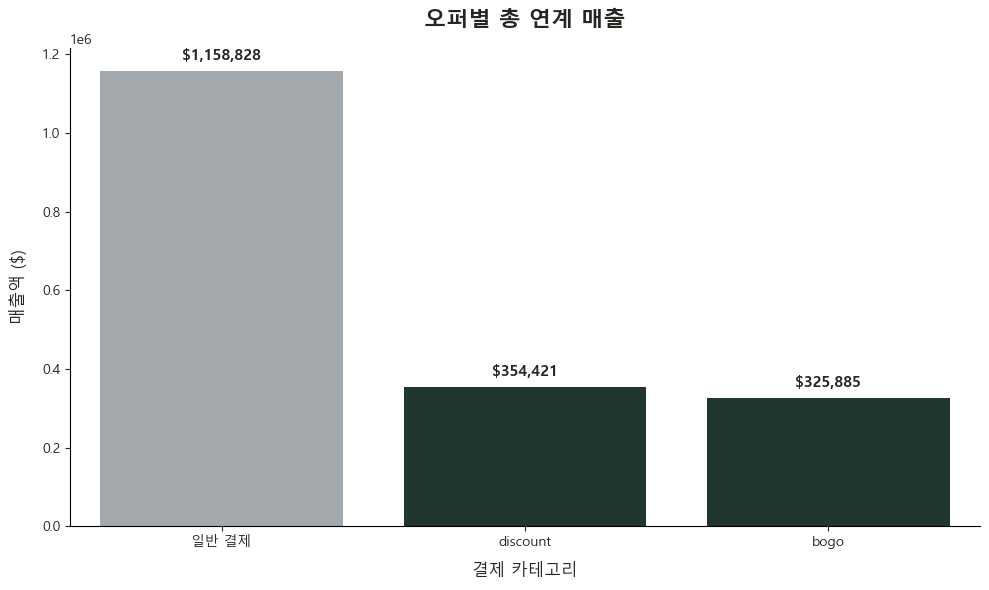

In [22]:
plt.figure(figsize=(10, 6))

color_palette = [SB_GREY, SB_DEEP_GREEN, SB_DEEP_GREEN]

ax = sns.barplot(
    data=revenue_summary, 
    x='category', 
    y='amount', 
    palette=color_palette
)

for container in ax.containers:
    labels = [f'${int(val):,}'  for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontweight='bold', color='#27251F', fontsize=11)

plt.title('오퍼별 총 연계 매출', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('매출액 ($)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

# 비상 : 오퍼별 총 연계 매출 수정

In [23]:
trans[trans['tx_offer_type']=='multi'].shape

(1390, 19)

In [27]:
revenue_summary = trans.groupby('tx_offer_type')['amount'].sum().reset_index()

# 출력용 이름
type_mapping = {
    'normal': '일반 결제',
    'discount': 'discount',
    'bogo': 'bogo',
    'multi': '다중 결제'
}
revenue_summary['category'] = revenue_summary['tx_offer_type'].map(type_mapping)

# 3. 순서 정렬
order_list = ['일반 결제', 'discount', 'bogo', '다중 결제']
revenue_summary['category'] = pd.Categorical(revenue_summary['category'], categories=order_list, ordered=True)
revenue_summary = revenue_summary.sort_values('category')

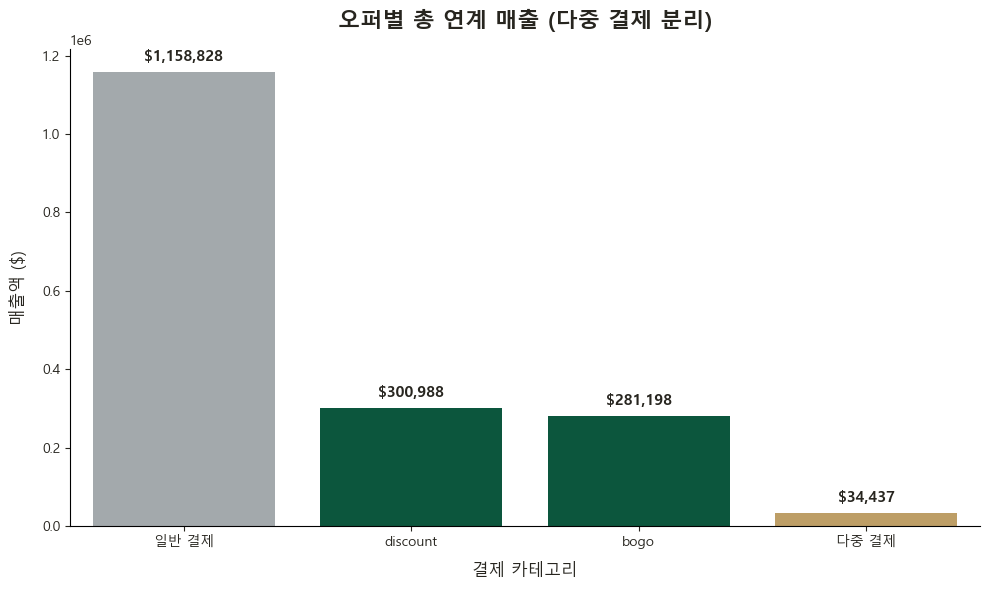

,category,amount
3,일반 결제,"$1,158,828.29"
1,discount,"$300,988.08"
0,bogo,"$281,198.52"
2,다중 결제,"$34,437.08"


In [28]:
plt.figure(figsize=(10, 6))

color_palette = [SB_GREY, SB_GREEN, SB_GREEN, SB_GOLD]

ax = sns.barplot(
    data=revenue_summary, 
    x='category', 
    y='amount', 
    palette=color_palette
)

# 숫자 표시
for container in ax.containers:
    labels = [f'${int(val):,}' for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontweight='bold', color='#27251F', fontsize=11)

plt.title('오퍼별 총 연계 매출 (다중 결제 분리)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('매출액 ($)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

# 데이터프레임 출력 확인
display(revenue_summary[['category', 'amount']].style.format({'amount': '${:,.2f}'}))

## 6. 발송 1건당 평균 매출

1건당 평균 매출 = 총매출액 / 총 발송 건수

In [29]:
# 1. 오퍼별로 총 발송 건수
sent_counts = received_df.groupby('offer_label').size().reset_index(name='sent_count')

# 2. 오퍼별 총 매출액 구하기
offer_revenue = sales_df.dropna(subset=['offer_label'])
revenue_per_offer = offer_revenue.groupby('offer_label')['amount'].sum().reset_index(name='total_revenue')

# 3. 데이터 합치기 (발송 건수 옆에 총매출액 붙이기)
roi_df = pd.merge(sent_counts, revenue_per_offer, on='offer_label', how='left')

# 빈칸은 0으로
roi_df['total_revenue'] = roi_df['total_revenue'].fillna(0)

# 4. 1건당 평균 매출 = 총매출액 / 총 발송 건수
roi_df['revenue_per_send($)'] = roi_df['total_revenue'] / roi_df['sent_count']

# 순서
roi_df = roi_df.sort_values(by='revenue_per_send($)', ascending=False).reset_index(drop=True)

오퍼별로 총 발송 건수

In [30]:
sent_counts

,offer_label,sent_count
0,bogo_1,7658
1,bogo_2,7593
2,bogo_3,7677
3,bogo_4,7571
4,discount_1,7668
5,discount_2,7646
6,discount_3,7597
7,discount_4,7632


오퍼별 총 매출

In [31]:
revenue_per_offer

,offer_label,total_revenue
0,bogo_1,87109.94
1,bogo_2,78562.14
2,bogo_3,77066.31
3,bogo_4,83146.93
4,discount_1,85985.53
5,discount_2,89848.17
6,discount_3,96900.08
7,discount_4,81687.95


1건당 평균 매출

In [32]:
roi_df

,offer_label,sent_count,total_revenue,revenue_per_send($)
0,discount_3,7597,96900.08,12.755045
1,discount_2,7646,89848.17,11.751003
2,bogo_1,7658,87109.94,11.375025
3,discount_1,7668,85985.53,11.213554
4,bogo_4,7571,83146.93,10.982292
5,discount_4,7632,81687.95,10.703348
6,bogo_2,7593,78562.14,10.346653
7,bogo_3,7677,77066.31,10.038597


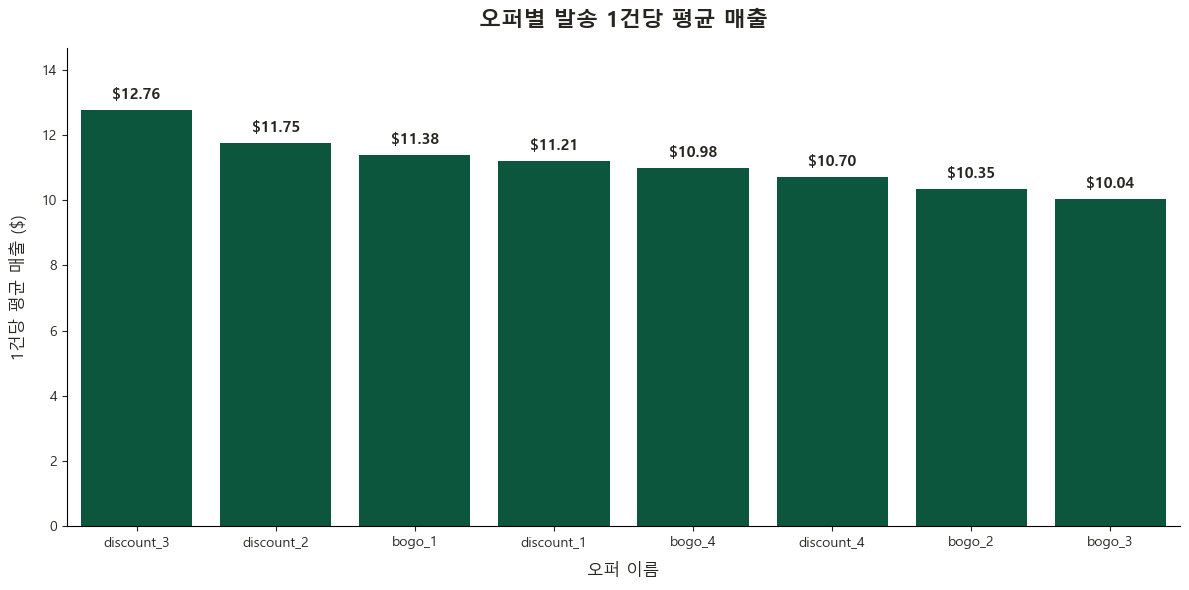


[오퍼별 효율성 상세 데이터]


,offer_label,sent_count,total_revenue,revenue_per_send($)
0,discount_3,"7,597 건","$96,900.08",$12.76
1,discount_2,"7,646 건","$89,848.17",$11.75
2,bogo_1,"7,658 건","$87,109.94",$11.38
3,discount_1,"7,668 건","$85,985.53",$11.21
4,bogo_4,"7,571 건","$83,146.93",$10.98
5,discount_4,"7,632 건","$81,687.95",$10.70
6,bogo_2,"7,593 건","$78,562.14",$10.35
7,bogo_3,"7,677 건","$77,066.31",$10.04


In [33]:

plt.figure(figsize=(12, 6))

SB_GREEN = '#006241'

ax = sns.barplot(
    data=roi_df, 
    x='offer_label', 
    y='revenue_per_send($)', 
    color=SB_GREEN 
)

labels = [f'${val:,.2f}' for val in ax.containers[0].datavalues]
ax.bar_label(ax.containers[0], labels=labels, padding=5, fontweight='bold', color='#27251F', fontsize=11)

plt.ylim(0, roi_df['revenue_per_send($)'].max() * 1.15)
plt.title('오퍼별 발송 1건당 평균 매출', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('오퍼 이름', fontsize=12, labelpad=10)
plt.ylabel('1건당 평균 매출 ($)', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

print("\n[오퍼별 효율성 상세 데이터]")
display(roi_df.style.format({
    'sent_count': '{:,} 건', 
    'total_revenue': '${:,.2f}',
    'revenue_per_send($)': '${:,.2f}'
}))

## 7. 오퍼 1건당 평균 매출

1건당 평균 매출 = 총매출액 / 총 발송 건수

In [34]:
completed_counts = completed_df.groupby('offer_label').size().reset_index(name='completed_count')
#일반결제 제외
offer_revenue = sales_df.dropna(subset=['offer_label'])
revenue_per_offer = offer_revenue.groupby('offer_label')['amount'].sum().reset_index(name='total_revenue')
# 데이터 합치기 (발송 건수 옆에 총매출액 붙이기)
roi_df = pd.merge(completed_counts, revenue_per_offer, on='offer_label', how='left')

roi_df['total_revenue'] = roi_df['total_revenue'].fillna(0)

# 1건당 평균 매출 = 총매출액 / 총 발송 건수
roi_df['revenue_per_completion($)'] = roi_df['total_revenue'] / roi_df['completed_count']
# 순서
roi_df = roi_df.sort_values(by='revenue_per_completion($)', ascending=False).reset_index(drop=True)

In [35]:
completed_counts

,offer_label,completed_count
0,bogo_1,3635
1,bogo_2,3301
2,bogo_3,4303
3,bogo_4,4262
4,discount_1,3340
5,discount_2,5112
6,discount_3,5265
7,discount_4,3964


In [36]:
revenue_per_offer

,offer_label,total_revenue
0,bogo_1,87109.94
1,bogo_2,78562.14
2,bogo_3,77066.31
3,bogo_4,83146.93
4,discount_1,85985.53
5,discount_2,89848.17
6,discount_3,96900.08
7,discount_4,81687.95


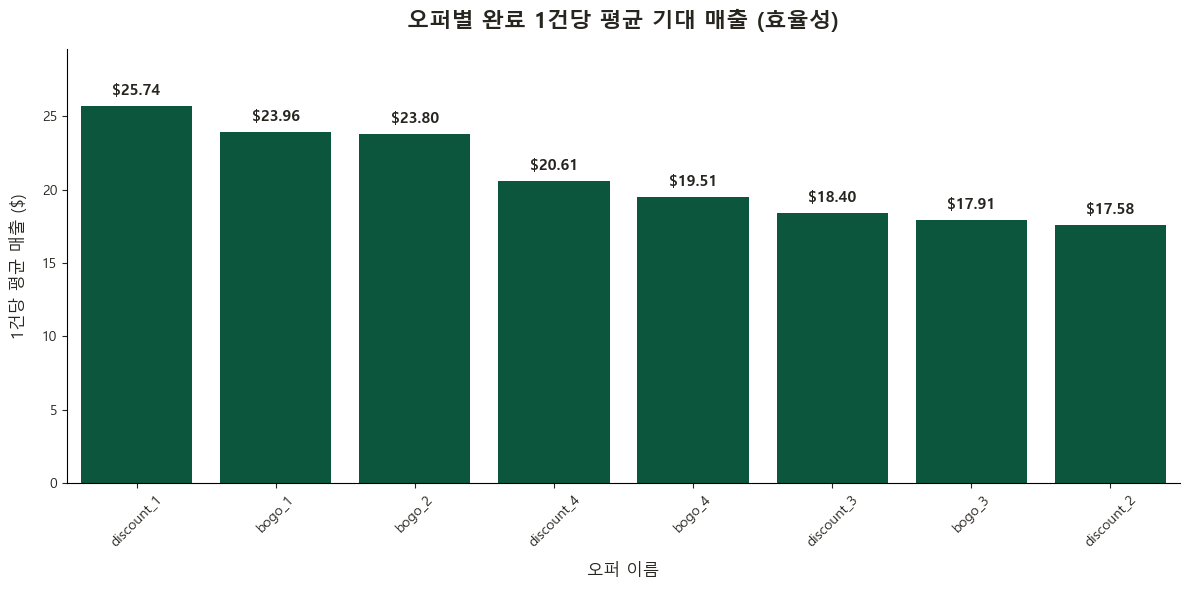


[오퍼별 완료 효율성 상세 데이터]


,offer_label,completed_count,total_revenue,revenue_per_completion($)
0,discount_1,"3,340 건","$85,985.53",$25.74
1,bogo_1,"3,635 건","$87,109.94",$23.96
2,bogo_2,"3,301 건","$78,562.14",$23.80
3,discount_4,"3,964 건","$81,687.95",$20.61
4,bogo_4,"4,262 건","$83,146.93",$19.51
5,discount_3,"5,265 건","$96,900.08",$18.40
6,bogo_3,"4,303 건","$77,066.31",$17.91
7,discount_2,"5,112 건","$89,848.17",$17.58


In [37]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=roi_df, 
    x='offer_label', 
    y='revenue_per_completion($)', 
    color=SB_GREEN 
)

# 숫자 붙이기
labels = [f'${val:,.2f}' for val in ax.containers[0].datavalues]
ax.bar_label(ax.containers[0], labels=labels, padding=5, fontweight='bold', color='#27251F', fontsize=11)

plt.ylim(0, roi_df['revenue_per_completion($)'].max() * 1.15)
plt.title('오퍼별 완료 1건당 평균 기대 매출 (효율성)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('오퍼 이름', fontsize=12, labelpad=10)
plt.ylabel('1건당 평균 매출 ($)', fontsize=12, labelpad=10)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n[오퍼별 완료 효율성 상세 데이터]")
display(roi_df.style.format({
    'completed_count': '{:,} 건', 
    'total_revenue': '${:,.2f}',
    'revenue_per_completion($)': '${:,.2f}'
}))

## 8. 오퍼별 거래 고객 ARPU


ARPU = 총 매출액 / 고유 고객 수

In [38]:
arpu_df = sales_df.copy()
arpu_df['offer_label'] = arpu_df['offer_label'].fillna('일반 결제')

# 오퍼 레이블 별로 총 매출
revenue_sum = arpu_df.groupby('offer_label')['amount'].sum().reset_index(name='total_revenue')

# 오퍼별 고유 결제 고객 수
unique_users = arpu_df.groupby('offer_label')['person'].nunique().reset_index(name='user_count')

# 총 매출과 고객 수 머지
arpu_summary = pd.merge(revenue_sum, unique_users, on='offer_label')

# ARPU = 총 매출액 / 고유 고객 수
arpu_summary['ARPU($)'] = arpu_summary['total_revenue'] / arpu_summary['user_count']

# 순서
arpu_summary = arpu_summary.sort_values(by='ARPU($)', ascending=False).reset_index(drop=True)

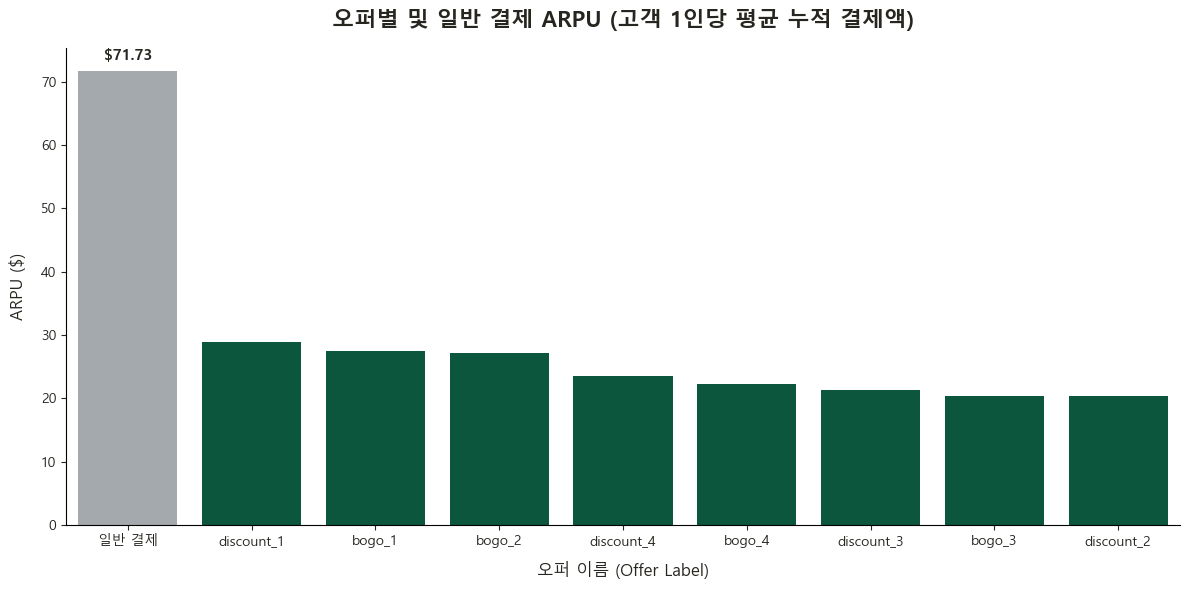


[오퍼별 및 일반 결제 ARPU]


,offer_label,total_revenue,user_count,ARPU($)
0,일반 결제,"$1,158,828.29","16,156 명",$71.73
1,discount_1,"$85,985.53","2,978 명",$28.87
2,bogo_1,"$87,109.94","3,177 명",$27.42
3,bogo_2,"$78,562.14","2,885 명",$27.23
4,discount_4,"$81,687.95","3,480 명",$23.47
5,bogo_4,"$83,146.93","3,741 명",$22.23
6,discount_3,"$96,900.08","4,530 명",$21.39
7,bogo_3,"$77,066.31","3,784 명",$20.37
8,discount_2,"$89,848.17","4,421 명",$20.32


In [39]:
plt.figure(figsize=(12, 6))
colors = ['#A2AAAD' if label == '일반 결제' else '#006241' for label in arpu_summary['offer_label']]

ax = sns.barplot(
    data=arpu_summary, 
    x='offer_label', 
    y='ARPU($)', 
    palette=colors
)

# 숫자
labels = [f'${val:,.2f}' for val in ax.containers[0].datavalues]
ax.bar_label(ax.containers[0], labels=labels, padding=5, fontweight='bold', color='#27251F', fontsize=11)


plt.title('오퍼별 및 일반 결제 ARPU (고객 1인당 평균 누적 결제액)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('오퍼 이름 (Offer Label)', fontsize=12, labelpad=10)
plt.ylabel('ARPU ($)', fontsize=12, labelpad=10)

sns.despine()
plt.tight_layout()
plt.show()

print("\n[오퍼별 및 일반 결제 ARPU]")
display(arpu_summary.style.format({
    'total_revenue': '${:,.2f}',
    'user_count': '{:,} 명',
    'ARPU($)': '${:,.2f}'
}))

# 비상 : 오퍼별 ARPU 

In [40]:
trans['tx_offer_type'].value_counts()

tx_offer_type
normal      108336
discount     15561
bogo         13666
multi         1390
Name: count, dtype: int64

multi의 기준이 bogo랑 discount 조합을 multi라고 함

bogo_1이랑 bogo_3 이렇게 같이 보내면 multi가 아닌 bogo 가 됨

In [41]:
import pandas as pd

# ['bogo_1', 'bogo_2'] 처럼 두 개 이상 적힌 데이터만 뽑음
multi_list_df = trans[trans['reward_offer_label_list'].str.contains(',', na=False)].copy()

# 확인
print(f"알맹이가 2개 이상인 데이터 총 건수: {len(multi_list_df):,}건")
display(multi_list_df[['person', 'amount', 'tx_offer_type', 'reward_offer_label_list']].head(10))

알맹이가 2개 이상인 데이터 총 건수: 2,505건


,person,amount,tx_offer_type,reward_offer_label_list
13,0011e0d4e6b944f998e987f904e8c1e5,22.05,multi,"['bogo_3', 'discount_1']"
17,0020c2b971eb4e9188eac86d93036a77,17.24,multi,"['bogo_2', 'discount_3']"
211,00ae03011f9f49b8a4b3e6d416678b0b,30.83,multi,"['bogo_1', 'discount_2']"
279,00c2f812f4604c8893152a5c6572030e,24.21,multi,"['bogo_2', 'discount_4']"
319,00cf1bbec83f4a658f8994e556db4633,33.28,discount,"['discount_3', 'discount_4']"
354,00d791e20c564add8056498e40eb56cc,10.38,bogo,"['bogo_2', 'bogo_3']"
361,00d7c95f793a4212af44e632fdc1e431,18.58,multi,"['bogo_3', 'discount_4']"
420,00ed7e22b32749cfafbfd88592d401d4,14.64,discount,"['discount_3', 'discount_4']"
453,0103de989e084e0fab400e80678d7591,20.20,discount,"['discount_1', 'discount_3']"
459,0103de989e084e0fab400e80678d7591,9.00,multi,"['bogo_4', 'discount_1']"


discount나 bogo에도 다중 오퍼

In [42]:
def create_exact_10_labels(row):
    txn_type = str(row['tx_offer_type']).strip().lower()
    
    if txn_type == 'normal':
        return '일반 결제'
    elif txn_type == 'multi':
        return '다중 오퍼'
    elif txn_type in ['bogo', 'discount']:
        label_list_str = str(row['reward_offer_label_list'])
        #뜯기
        clean_label = label_list_str.replace('[', '').replace(']', '').replace("'", "").replace('"', '').strip()
        
        # 청소 후 글자에 쉼표가 있다면 bogo_1, bogo_2 같은 것 -> 다중 오퍼
        if ',' in clean_label:
            return '다중 오퍼'
            
        # 제외
        if 'informational' in clean_label: 
            return None
            
        return clean_label 
    else:
        return None

trans_plot = trans.copy()
trans_plot['final_label'] = trans_plot.apply(create_exact_10_labels, axis=1)

trans_plot = trans_plot.dropna(subset=['final_label'])


In [43]:
arpu_summary = trans_plot.groupby('final_label').agg(
    total_revenue=('amount', 'sum'), # 총 매출
    user_count=('person', 'nunique') # 유저 카운트
).reset_index()

arpu_summary['ARPU($)'] = arpu_summary['total_revenue'] / arpu_summary['user_count']
arpu_summary = arpu_summary.sort_values(by='ARPU($)', ascending=False).reset_index(drop=True)
arpu_summary


,final_label,total_revenue,user_count,ARPU($)
0,일반 결제,1158828.29,16156,71.727426
1,discount_1,63811.75,2320,27.505065
2,bogo_1,72251.56,2690,26.859316
3,bogo_2,66567.32,2494,26.690986
4,다중 오퍼,61749.85,2410,25.622344
5,discount_4,65247.52,2935,22.230842
6,bogo_4,70338.90,3304,21.289013
7,discount_3,79538.92,3944,20.167069
8,bogo_3,62767.30,3230,19.432601
9,discount_2,74350.56,3915,18.991203


시각화

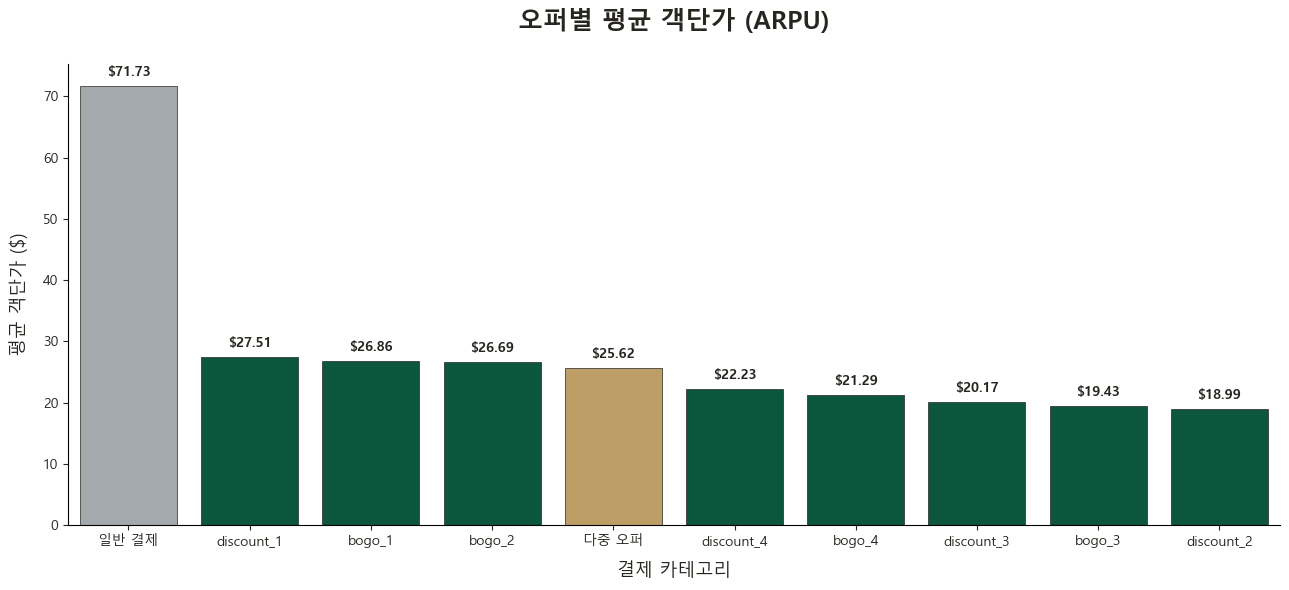

In [44]:
# 컬러 매핑
def get_sb_color(label):
    if label == '일반 결제':
        return SB_GREY
    elif label == '다중 오퍼':
        return SB_GOLD 
    else:
        return SB_GREEN 

plt.figure(figsize=(13, 6))

# 컬러 리스트
plot_colors = [get_sb_color(label) for label in arpu_summary['final_label']]

ax = sns.barplot(
    data=arpu_summary, 
    x='final_label', 
    y='ARPU($)', 
    palette=plot_colors,
    edgecolor=SB_BLACK,
    linewidth=0.5
)

for i, container in enumerate(ax.containers):
    labels = [f'${val:,.2f}' if pd.notnull(val) else '' for val in container.datavalues]
    ax.bar_label(
        container, 
        labels=labels, 
        padding=5, 
        fontweight='bold', 
        color=SB_BLACK, 
        fontsize=10
    )

plt.title('오퍼별 평균 객단가 (ARPU)', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('결제 카테고리', fontsize=13, labelpad=10)
plt.ylabel('평균 객단가 ($)', fontsize=13, labelpad=10)

plt.tight_layout()
plt.show()

# 2. 이전에 했던 오퍼별 채널별 성과 요약 & 시각화

In [45]:
merge_df.head(1)

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label
0,0009655768c64bdeb2e877511632db8f,completed,576,2906b810c7d4411798c6938adc9daaa5,NaN,2.0,25,M,33.0,0009655768c64bdeb2e877511632db8f,2017-04-21,72000.0,0,0,2.0,10.0,7.0,1.0,1.0,1.0,0.0,discount_4,2,0,0.0,NaN


#### noinfo_merge_df : informational이 없는 merge_df

In [46]:
exclude_labels = ['informational_1', 'informational_2']

noinfo_merge_df = merge_df[~merge_df['offer_label'].isin(exclude_labels)]

print("남아있는 오퍼:", noinfo_merge_df['offer_label'].unique())

남아있는 오퍼: <StringArray>
['discount_4',     'bogo_4', 'discount_3',          nan, 'discount_1',
 'discount_2',     'bogo_3',     'bogo_2',     'bogo_1']
Length: 9, dtype: str


In [47]:
ex_shape = merge_df.shape
print(ex_shape)

noinfo_shape = noinfo_merge_df.shape
print(noinfo_shape)

(306137, 26)
(280071, 26)


## 대시보드 1 : 전체 핵심지표

## 1-1. 총 오퍼 퍼널 분석 (총 발송 수, 총 열람 수, 총 완료 수)

Received 건수: 76,277
Viewed 건수: 57,725
Completed 건수: 33,182


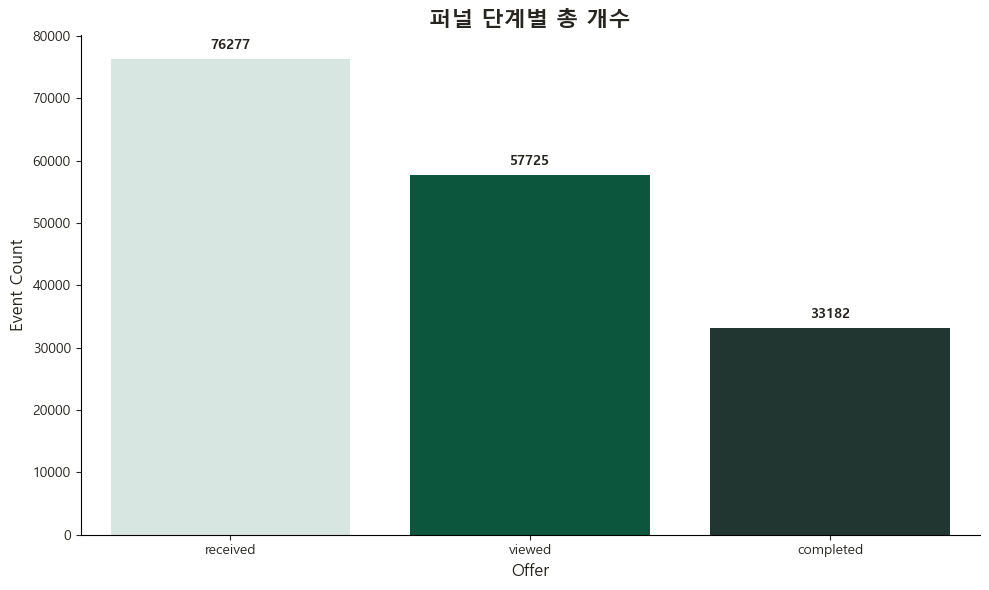

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

offer_events = ['received', 'viewed', 'completed']
event_counts = merge_df['event'].value_counts().reindex(offer_events)

print(f"Received 건수: {event_counts['received']:,}")
print(f"Viewed 건수: {event_counts['viewed']:,}")
print(f"Completed 건수: {event_counts['completed']:,}")

plot_df = event_counts.reset_index()
plot_df.columns = ['Stage', 'Count']

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=plot_df, x='Stage', y='Count', 
                 palette=[SB_LIGHT_GREEN, SB_GREEN, SB_DEEP_GREEN], 
                 hue='Stage', legend=False)

for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold')

plt.title('퍼널 단계별 총 개수', fontsize=16, fontweight='bold')
plt.ylabel('Event Count', fontsize=12)
plt.xlabel('Offer', fontsize=12)

plt.tight_layout()
plt.show()

## 1-2. 총 오퍼 퍼널 분석 (오퍼 단계별 전환율)

앞에 맞춰서 뒤의 비율

태블로에서는 각각

거래 기준 -> 제외

In [49]:
event_counts = noinfo_merge_df['event'].value_counts().reindex(offer_events)

오퍼 반응률 (Received -> Viewed): 76.82%
오퍼 반응률 (Viewed -> Completed): 70.76%


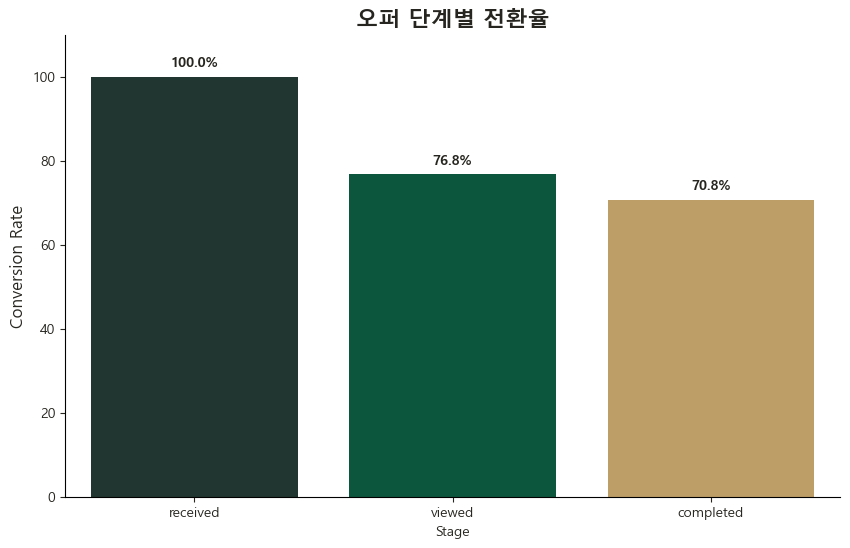

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

#오퍼 열람률과 오퍼 반응률 구하기
rv_rate = (event_counts['viewed'] / event_counts['received']) * 100
vc_rate = (event_counts['completed'] / event_counts['viewed']) * 100

print(f"오퍼 반응률 (Received -> Viewed): {rv_rate:.2f}%")
print(f"오퍼 반응률 (Viewed -> Completed): {vc_rate:.2f}%")


rates = [100, rv_rate, vc_rate] 
rate_df = pd.DataFrame({'Stage': offer_events, 'Rate': rates})

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=rate_df, x='Stage', y='Rate', 
                 palette=[SB_DEEP_GREEN, SB_GREEN, SB_GOLD], 
                 hue='Stage', legend=False)
                 
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontweight='bold')

plt.title('오퍼 단계별 전환율', fontsize=16, fontweight='bold')
plt.ylabel('Conversion Rate', fontsize=12)
plt.ylim(0, 110) 
plt.show()

## 2. 총 매출

In [51]:
transaction_df = noinfo_merge_df[noinfo_merge_df['event'] == 'transaction']

total_revenue = transaction_df['amount'].sum()

print(f"총 매출액: ${total_revenue:,.2f}")

총 매출액: $1,775,451.97


## 3. 총 거래 건수

In [52]:
total_trans_count = len(transaction_df)

print(f"총 거래 건수: {total_trans_count:,} 건")

총 거래 건수: 138,953 건


## 4. 거래 건당 객단가

객단가 = 총 매출 / 총 거래 건수

거래 기준 -> 제외

In [53]:
aov = total_revenue / total_trans_count

print(f"평균 객단가(AOV): ${aov:.2f}")

평균 객단가(AOV): $12.78


## 5. 전체 고객 수

오퍼기준 -> 포함

In [54]:
unique_customers = merge_df['person'].nunique()
print(f"전체 고유 고객 수: {unique_customers}명")

전체 고유 고객 수: 17000명


## 6. 채널별 고객 수

각 채널별로 값이 1인 행들에서 고유한 'person' 수를 집계

해당 채널 값이 1인 데이터만 필터링해서 고유 인원수 체크

오퍼 기준 -> 포함

In [55]:
merge_df[['web','email','mobile','social']].head()

,web,email,mobile,social
0,1.0,1.0,1.0,0.0
1,1.0,1.0,1.0,0.0
2,1.0,1.0,1.0,0.0
3,1.0,1.0,1.0,0.0
4,0.0,1.0,1.0,1.0


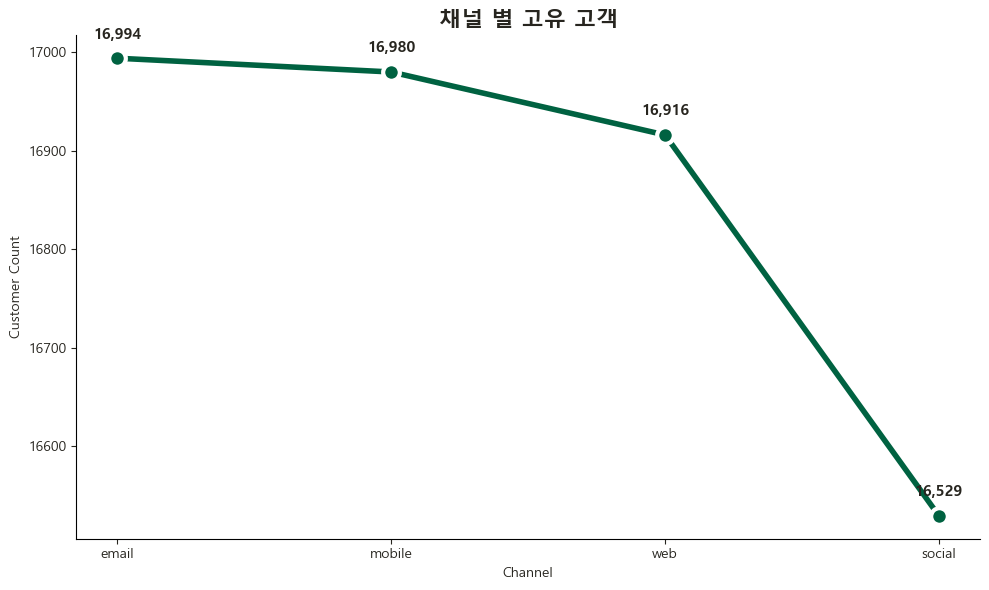

In [57]:
plt.figure(figsize=(10, 6))

ax = sns.lineplot(data=channel_df, x='Channel', y='Unique_Customers', 
                marker='o', markersize=12, linewidth=4, 
                color=SB_GREEN,  # 선 색상
                markeredgewidth=3)

for i, val in enumerate(channel_df['Unique_Customers']):
    plt.text(i, val + 20, f'{val:,}', ha='center', fontweight='bold', fontsize=11)

plt.title('채널 별 고유 고객', fontsize=16, fontweight='bold')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()

## 7. completed된 거래중 viewed된 비율

쿠폰 보고 완료: 28,382 건
쿠폰 안 보고 완료: 4,800 건


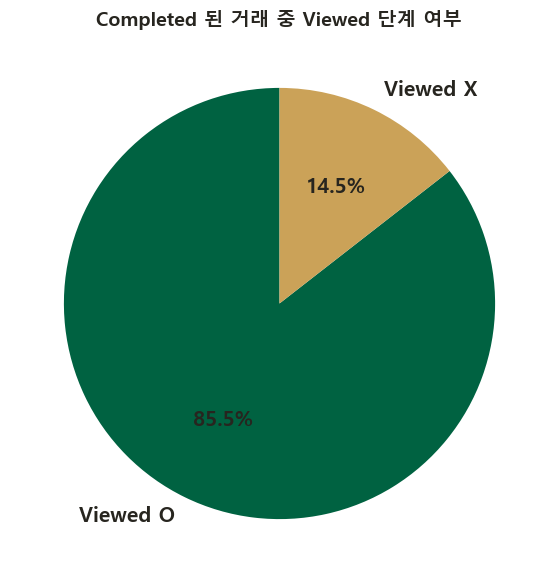

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

completed_data = merge_df[merge_df['event'] == 'completed']
viewed_data = merge_df[merge_df['event'] == 'viewed']

viewed_users = viewed_data[['person', 'offer_id']].drop_duplicates()
viewed_users['is_viewed'] = True 

check_df = pd.merge(completed_data, viewed_users, on=['person', 'offer_id'], how='left')

check_df['is_viewed'] = check_df['is_viewed'].fillna(False)

true_roi = len(check_df[check_df['is_viewed'] == True])
accidental_roi = len(check_df[check_df['is_viewed'] == False])

print(f"쿠폰 보고 완료: {true_roi:,} 건")
print(f"쿠폰 안 보고 완료: {accidental_roi:,} 건")


labels = ['Viewed O', 'Viewed X']
sizes = [true_roi, accidental_roi]

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=[SB_GREEN, SB_GOLD],
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 15, 'fontweight': 'bold'})


plt.title('Completed 된 거래 중 Viewed 단계 여부', fontsize=14, fontweight='bold')
plt.show()

## 8. 오퍼 종류 별 고객이 Completed까지 걸리는 time 평균

Completed까지 완료한 로그 중 오퍼별로 그룹 -> 평균

informational은 completed가 X -> 제거

In [59]:
completed_df = noinfo_merge_df[noinfo_merge_df['event'] == 'completed']

avg_completion_time = completed_df.groupby('offer_label')['time'].mean().sort_values()

print("오퍼별 평균 완료 시점")
print(avg_completion_time)

오퍼별 평균 완료 시점
offer_label
bogo_4        381.819334
bogo_2        384.539836
bogo_1        393.053645
discount_3    397.862108
discount_2    399.349765
bogo_3        405.696491
discount_4    408.381433
discount_1    429.556886
Name: time, dtype: float64


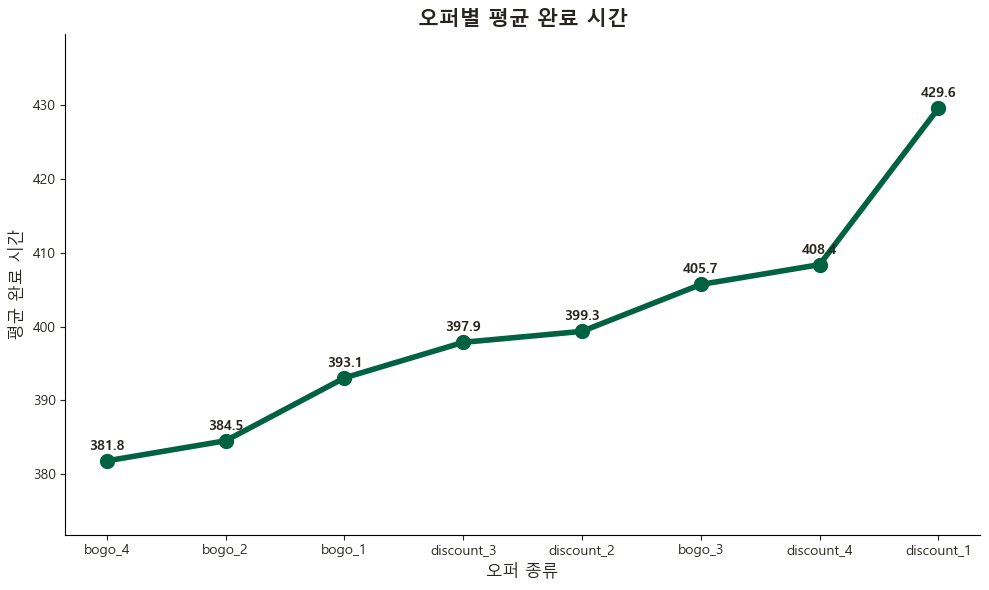

In [60]:
plt.figure(figsize=(10, 6))

plt.plot(avg_completion_time.index, avg_completion_time.values, 
         marker='o', linestyle='-', linewidth=4, markersize=8, 
         color=SB_GREEN,        
         markeredgewidth=3)

y_min = avg_completion_time.min() - 10
y_max = avg_completion_time.max() + 10
plt.ylim(y_min, y_max)

for i, v in enumerate(avg_completion_time.values):
    plt.text(i, v + 1.5, f"{v:.1f}", ha='center', fontsize=10, fontweight='bold')

plt.title('오퍼별 평균 완료 시간', fontsize=15, fontweight='bold')
plt.xlabel('오퍼 종류', fontsize=12)
plt.ylabel('평균 완료 시간', fontsize=12)

plt.tight_layout()
plt.show()

## 대시보드 2 : 오퍼/채널별 성과 요약

## 1. 오퍼별

## 1-1. 총 발송 수

In [61]:
total_received = len(merge_df[merge_df['event'] == 'received'])

print(f"총 발송 수 : {total_received:,} 건")

총 발송 수 : 76,277 건


## 1-2. 총 열람 수

In [62]:
total_viewed = len(merge_df[merge_df['event'] == 'viewed'])

print(f"총 열람 수 : {total_viewed:,} 건")

총 열람 수 : 57,725 건


## 1-3. 총 완료 수

In [63]:
total_completed = len(merge_df[merge_df['event'] == 'completed'])

print(f"총 완료 수 : {total_completed:,}")

총 완료 수 : 33,182


## 1-4. 전체 완료율

In [64]:
total_completion_rate = (total_completed / total_received) * 100

print(f"전체 오퍼 완료율: {total_completion_rate:.2f}%")

전체 오퍼 완료율: 43.50%


## 2. <<오퍼 효율 분석>>

x축 : 완료율

y축 : 발송 1건당 매출

점크기 : 총 매출 

색상 : 오퍼 유형

informatinal 제외

##### x축 : 완료율 (viewed -> completed)

In [65]:
df_core = merge_df[merge_df['offer_label'].notna()].copy()
df_core = df_core[~df_core['offer_label'].str.contains('informational')]

print(df_core['offer_label'].value_counts())

received_cnt = df_core[df_core['event'] == 'received'].groupby('offer_label')['person'].count()
viewed_cnt = df_core[df_core['event'] == 'viewed'].groupby('offer_label')['person'].count()

# 같은 사람이 같은 오퍼를 여러번 본 경우 처음 봤을 때만 남김
viewed_events = df_core[df_core['event'] == 'viewed'][['person', 'offer_label', 'time']].rename(columns={'time': 'viewed_time'})
viewed_events = viewed_events.groupby(['person', 'offer_label'])['viewed_time'].min().reset_index()


completed_events = df_core[df_core['event'] == 'completed'][['person', 'offer_label', 'time']].rename(columns={'time': 'completed_time'})

# 같은 사람과 같은 오퍼를 기준으로 viewed와 completed 연결
true_comp_df = pd.merge(completed_events, viewed_events, on=['person', 'offer_label'], how='left')
true_comp_df = true_comp_df[
    (true_comp_df['viewed_time'].notna()) &
    (true_comp_df['viewed_time'] <= true_comp_df['completed_time'])
]

true_completed_cnt = true_comp_df.groupby('offer_label')['person'].count()

print("\n Viewed -> Completed 만족",true_completed_cnt)

offer_label
discount_3    20189
discount_2    20095
bogo_4        19097
bogo_2        18192
bogo_1        18009
bogo_3        16151
discount_4    15714
discount_1    13671
Name: count, dtype: int64

 Viewed -> Completed 만족 offer_label
bogo_1        2758
bogo_2        2852
bogo_3        2333
bogo_4        3647
discount_1    1451
discount_2    4509
discount_3    4766
discount_4    2298
Name: person, dtype: int64


##### y축 : 발송 1건당 매출 

In [66]:
transactions = merge_df[merge_df['event'] == 'transaction'][['person', 'time', 'amount']]

true_completions_for_rev = true_comp_df[['person', 'completed_time', 'offer_label']].rename(columns={'completed_time': 'time'})

# 오퍼 완료한 순간의 거래만 가져옴 (해찬님 코드 참고)
matched_sales = pd.merge(transactions, true_completions_for_rev, on=['person', 'time'], how='inner')

# 오퍼별 총 매출 집계
revenue_df = matched_sales.groupby('offer_label').agg(
    total_offer_revenue=('amount', 'sum')
)

revenue_df

,total_offer_revenue
offer_label,
bogo_1,65084.60
bogo_2,68123.31
bogo_3,42701.11
bogo_4,73038.10
discount_1,37830.57
discount_2,77078.86
discount_3,85729.59
discount_4,46485.54


#####  KPI 통합 

In [67]:
final_kpi_df = pd.DataFrame({
    'received_cnt': received_cnt,
    'viewed_cnt': viewed_cnt,
    'true_completed_cnt': true_completed_cnt
}).fillna(0).join(revenue_df).fillna(0)

final_kpi_df

,received_cnt,viewed_cnt,true_completed_cnt,total_offer_revenue
offer_label,,,,
bogo_1,7658,6716,2758,65084.60
bogo_2,7593,7298,2852,68123.31
bogo_3,7677,4171,2333,42701.11
bogo_4,7571,7264,3647,73038.10
discount_1,7668,2663,1451,37830.57
discount_2,7646,7337,4509,77078.86
discount_3,7597,7327,4766,85729.59
discount_4,7632,4118,2298,46485.54


##### X축 : 실제 완료율 = 실제 완료 수 / 총 발송 수 (여기서 실제란 Viewed -> Completed 과정을 거침)

#####  Y축 : 발송 1건당 매출 = 총 오퍼 연계 매출 / 총 발송 수

In [68]:
final_kpi_df['true_completed_rate'] = (final_kpi_df['true_completed_cnt'] / final_kpi_df['received_cnt'] * 100).round(2)

final_kpi_df['revenue_per_send'] = (final_kpi_df['total_offer_revenue'] / final_kpi_df['received_cnt']).round(2)

색상 구분 위해서 BOGO, Discount 그룹 묶고 컬럼 추가

In [69]:
final_kpi_df = final_kpi_df.reset_index()
final_kpi_df['offer_type'] = final_kpi_df['offer_label'].apply(lambda x: 'bogo' if 'bogo' in x else 'discount')

분모에 0들어가면 에러 위험 -> nan으로 채움

In [70]:
final_kpi_df['received_cnt'] = final_kpi_df['received_cnt'].replace(0, np.nan)

##### 산점도 그리기

| 요소 | 의미                   |
| -- | -------------------- |
| X축 | 완료율 (얼마나 잘 전환되었는지)     |
| Y축 | 발송당 매출 (얼마나 돈 잘 벌었는지) |
| 크기 | 총매출 (얼마나 크게 벌었는지)     |
| 색  | 오퍼 유형                |


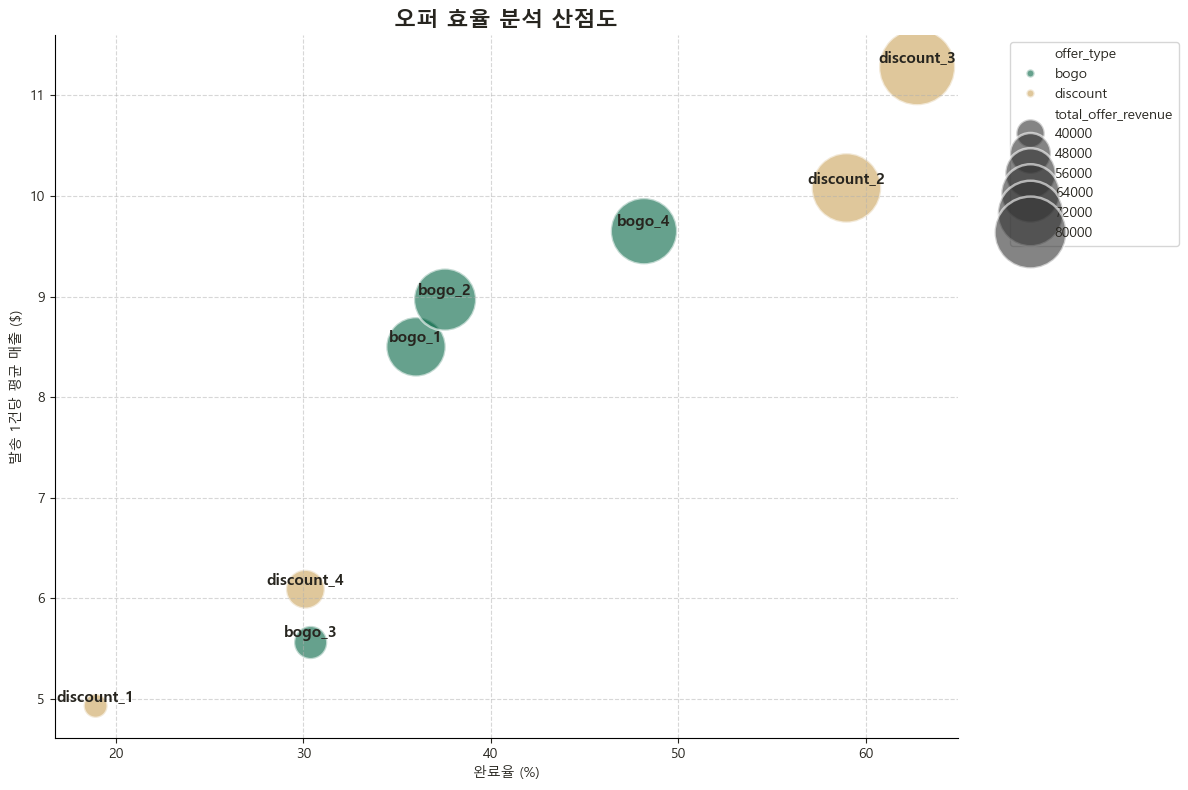

In [71]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=final_kpi_df,
    x='true_completed_rate', # 완료율
    y='revenue_per_send', # 발송 1건당 평균 매출
    size='total_offer_revenue', # 총 매출
    hue='offer_type',  # 색상 구분
    sizes=(300, 3000),
    alpha=0.6,
)

# 라벨 추가
for i in range(len(final_kpi_df)):
    plt.text(
        final_kpi_df['true_completed_rate'].iloc[i],
        final_kpi_df['revenue_per_send'].iloc[i] + 0.05,
        final_kpi_df['offer_label'].iloc[i],
        ha='center',
        fontsize=11,
        fontweight='bold',
        color=SB_BLACK
    )

plt.title('오퍼 효율 분석 산점도', fontsize=16, fontweight='bold')
plt.xlabel('완료율 (%)')
plt.ylabel('발송 1건당 평균 매출 ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### 해석

오른쪽에 있을수록 고객들이 좋아하고 잘 참여하는 오퍼 (높은 완료율)

위에 있을수록 한 번 발송할 때마다 돈을 많이 벌어다 주는 오퍼 (높은 수익성)

점이 클수록 회사 전체 매출에 기여하는 바가 큰 오퍼 (큰 규모)

색깔은 이게 BOGO인지 Discount인지 구분 (오퍼 유형)

### 알 수 있는 것

1. discount_3과 discount_2의 높은 완료율과 높은 원의 크기 (총 매출)

-> 고객들이 쉽게 참여하면서도 돈을 많이 쓰게 하는 최고의 오퍼

2. 중앙에 모여있는 bogo_1, bogo_2, bogo_4

-> 최고 1등은 아니지만 안정적인 성과를 보여줌

3. 하단에 있는 오퍼들 discount_1, discount_4, bogo_3

-> 완료율도 30% 이하이며 건당 매출도 5~6$로 낮음, 조건이 까다롭거나 보상이 별로?

4. 할인 쿠폰은 조건을 어떻게 짜느냐에 따라 큰 차이가 남